In [1]:
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

In [22]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np

METHOD_LABELS = {
    'normative_union': 'Normative (Pooled)',
    'normative_recur3': 'Normative (Recurrence ≥ 3)',
    'deseq2_no_cov': 'DESeq2 (No Covariates)',
    'deseq2_cov': 'DESeq2 (with Covariates)',
    'deseq2_ruvg_k1': 'DESeq2 (RUVg, k1)',
    'deseq2_ruvg_k2': 'DESeq2 (RUVg, k2)',
    'deseq2_ruvg_k3': 'DESeq2 (RUVg, k3)',
}

def pretty(m):
    return METHOD_LABELS.get(m, m)

def method_family(m):
    m_lower = str(m).lower()
    if 'normative' in m_lower:
        return 'normative'
    if 'ruvg' in m_lower:
        return 'deseq2_ruvg'
    return 'deseq2_cov'

METHOD_COLORS = {
    'normative_union': "#af1810",    
    'normative_recur3': "#fa624e",   
    'deseq2_no_cov': '#9bb4a6',      
    'deseq2_cov': '#c1d3c9',        
    'deseq2_ruvg_k1': '#bfaec9',     
    'deseq2_ruvg_k2': '#d2c4dc',    
    'deseq2_ruvg_k3': '#e5dceb',     
}

def family_colors(methods):
    mcolor = {}
    for m in methods:
        mcolor[m] = METHOD_COLORS.get(m, '#999999')
    return mcolor

def plot_db_hit_bars(rates, fname="db_hit_horizontal.png", scale='log', 
                        save=True, show_pooled=True, method_order=None, dc=None):
    sub = rates[rates.has_ot_ref].copy()
    phenos = sorted(sub.phenotype.unique(), reverse=True)
    raw_methods = list(dict.fromkeys(sub.method))
    if method_order is not None:
        methods = [m for m in method_order if m in sub['method'].unique()]
        remaining = [m for m in raw_methods if m not in methods]
        methods.extend(remaining)
    else:
        def method_priority(m):
            m_lower = str(m).lower()
            if 'normative' in m_lower:
                return (0, raw_methods.index(m))
            explicit_order = ['deseq_no_cov', 'deseq_cov', 'deseq_ruvg1', 'deseq_ruvg2', 'deseq_ruvg3', 'deseq2']
            for idx, pattern in enumerate(explicit_order):
                if pattern in m_lower:
                    return (idx + 1, raw_methods.index(m))
            return (999, raw_methods.index(m))
        methods = sorted(raw_methods, key=method_priority)
        
    mcolor = family_colors(methods)
    fig_height = max(6, len(phenos) * 1)
    
    if show_pooled:
        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(14, fig_height), 
            gridspec_kw={'width_ratios': [2.5, 1]}
        )
    else:
        fig, ax1 = plt.subplots(figsize=(9, fig_height))
        ax2 = None
        
    y_indices = np.arange(len(phenos))
    n_methods = len(methods)
    bar_height = 0.7 / n_methods
    
    for j, method in enumerate(methods):
        c = mcolor[method]
        offset = ((n_methods - 1) / 2 - j) * bar_height
        y_pos = y_indices + offset
        n_sig_vals = []
        n_db_vals = []
        for pheno in phenos:
            row = sub[(sub.phenotype == pheno) & (sub.method == method)]
            if not row.empty:
                n_sig_vals.append(row['n_sig'].values[0])
                n_db_vals.append(row['n_db'].values[0])
            else:
                n_sig_vals.append(0)
                n_db_vals.append(0)
                
        ax1.barh(y_pos, n_sig_vals, height=bar_height * 0.85, 
                 facecolor='none', edgecolor=c, linewidth=1)
        ax1.barh(y_pos, n_db_vals, height=bar_height * 0.85, 
                 facecolor=c, edgecolor='none', alpha=0.9)

    ax1.set_yticks(y_indices)
    ax1.set_yticklabels(phenos)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=mcolor[m], edgecolor='none') for m in methods]
    ax1.legend(handles, [pretty(m) for m in methods], loc='upper center',
               bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

    if ax2 is not None:
        x_pos = np.arange(n_methods)
        for i, method in enumerate(methods):
            c = mcolor[method]
            m_sub = sub[sub.method == method]
            sig_sum = m_sub['n_sig'].sum()
            db_sum = m_sub['n_db'].sum()
            rate = (db_sum / sig_sum) if sig_sum > 0 else 0
            ax2.bar(i, sig_sum, width=0.6, facecolor='none', edgecolor='gray', linewidth=1.2)
            ax2.bar(i, db_sum, width=0.6, facecolor=c, edgecolor='none')
            if sig_sum > 0:
                ax2.text(i, db_sum + (sig_sum * 0.01), f"{int(db_sum)}\n({rate:.2f})", 
                         ha='center', va='bottom')

        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([pretty(m) for m in methods], rotation=90, ha='right')
        ax2.set_ylabel('pooled term count', fontsize=11)
        if scale == 'log':
            ax2.set_yscale('log')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
    plt.tight_layout()

    if save:
        base_dir = dc.HERE if dc is not None else pathlib.Path('.')
        save_dir = base_dir / 'Figures'
        save_dir.mkdir(exist_ok=True)
        fig.savefig(save_dir / fname, bbox_inches='tight', dpi=300)

    return fig

In [23]:
GENE_RATES_PATH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_db_hit_rates.csv'
GENE_PERSAMPLE_PATH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'gene_db_hit_rates_persample.csv'
if os.path.exists(GENE_RATES_PATH):
    rates = pd.read_csv(GENE_RATES_PATH)
    persample = pd.read_csv(GENE_PERSAMPLE_PATH)
    persample_summary = (persample[persample.has_ot_ref].groupby('phenotype')['db_hit_rate']
                          .agg(['median', 'count']).reset_index())
else:
    rates, persample_summary = dc.gene_level_db_hits(save=True)
print('== gene-level DB-hit rate (cohort-level sets) ==')
display(rates[rates.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))
print()
print('== per-patient normative rate distribution (median across patients) ==')
display(persample_summary)

== gene-level DB-hit rate (cohort-level sets) ==


,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov,49,2,0.041,True
1,Colorectal Cancer,deseq2_no_cov,10041,192,0.019,True
2,Colorectal Cancer,deseq2_ruvg_k1,611,19,0.031,True
3,Colorectal Cancer,deseq2_ruvg_k2,88,1,0.011,True
4,Colorectal Cancer,deseq2_ruvg_k3,93,3,0.032,True
...,...,...,...,...,...,...
88,Tuberculosis,deseq2_ruvg_k1,1619,57,0.035,True
89,Tuberculosis,deseq2_ruvg_k2,782,29,0.037,True
90,Tuberculosis,deseq2_ruvg_k3,136,10,0.074,True
91,Tuberculosis,normative_recur3,1,0,0.000,True



== per-patient normative rate distribution (median across patients) ==


,phenotype,median,count
0,Colorectal Cancer,0.0,24
1,Esophagus Cancer,0.0,20
2,HIV,0.0,10
3,HIV + Tuberculosis,0.0,4
4,Liver Cancer,0.0,37
5,Liver Cirrhosis,0.0,4
6,Lung Cancer,0.0,23
7,ME/CFS,0.0,22
8,MM,0.0,16
9,Pancreatic Cancer,0.0,72


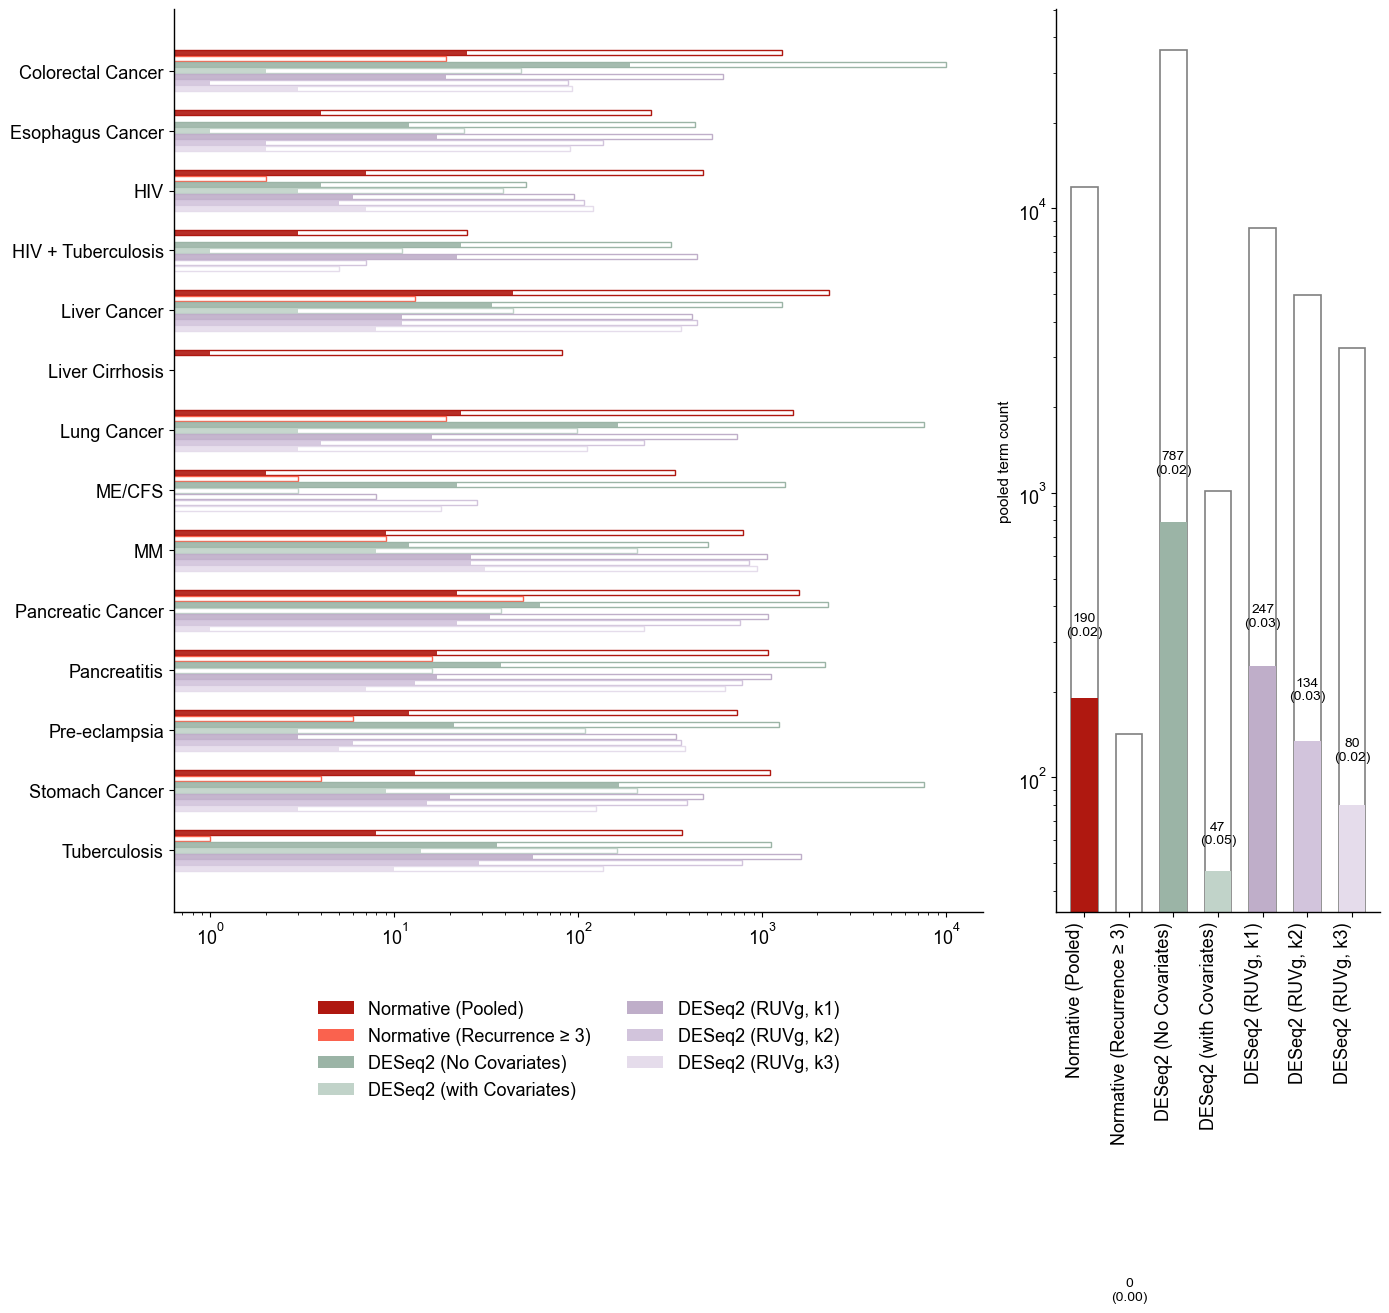

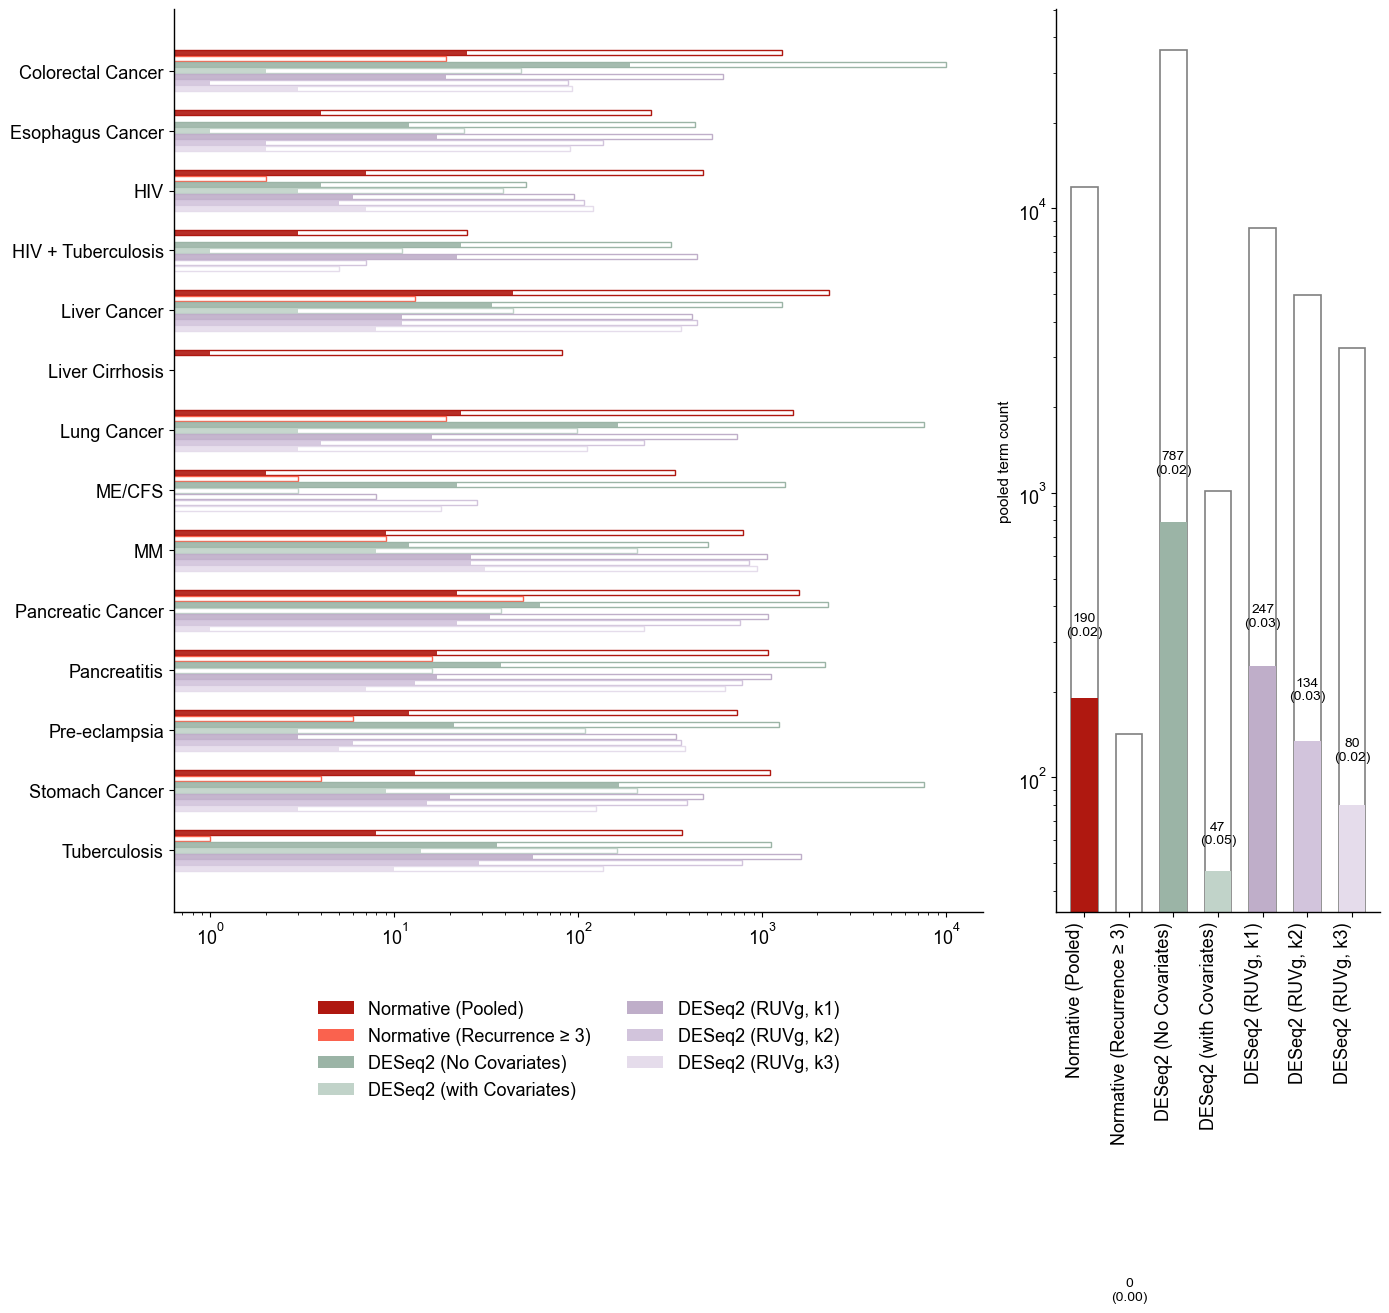

In [24]:
plot_db_hit_bars(rates, fname='gene_db_hit_bars.png', dc=dc)

In [25]:
PATHWAY_RATES_PATH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'pathway_db_hit_rates.csv'
if os.path.exists(PATHWAY_RATES_PATH):
    path_rates = pd.read_csv(PATHWAY_RATES_PATH)
else:
    path_rates = dc.pathway_level_db_hits(save=True)
display(path_rates[path_rates.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov,0,0,NaN,True
1,Colorectal Cancer,deseq2_no_cov,184,79,0.429,True
2,Colorectal Cancer,deseq2_ruvg_k1,20,5,0.250,True
3,Colorectal Cancer,deseq2_ruvg_k2,29,11,0.379,True
4,Colorectal Cancer,deseq2_ruvg_k3,13,6,0.462,True
...,...,...,...,...,...,...
58,Tuberculosis,deseq2_ruvg_k1,373,166,0.445,True
59,Tuberculosis,deseq2_ruvg_k2,302,142,0.470,True
60,Tuberculosis,deseq2_ruvg_k3,254,111,0.437,True
61,Tuberculosis,normative_recur3,1195,360,0.301,True


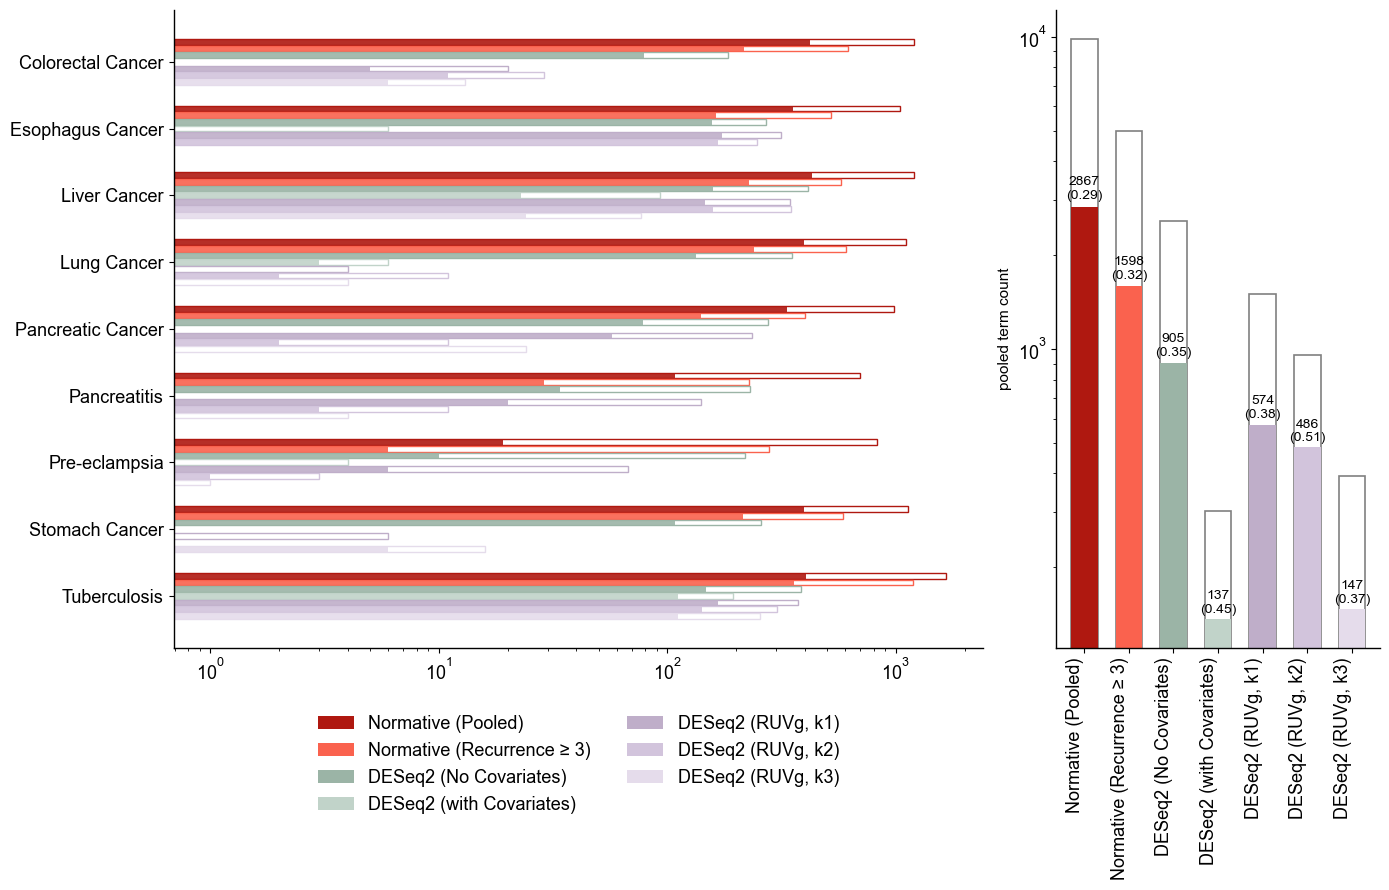

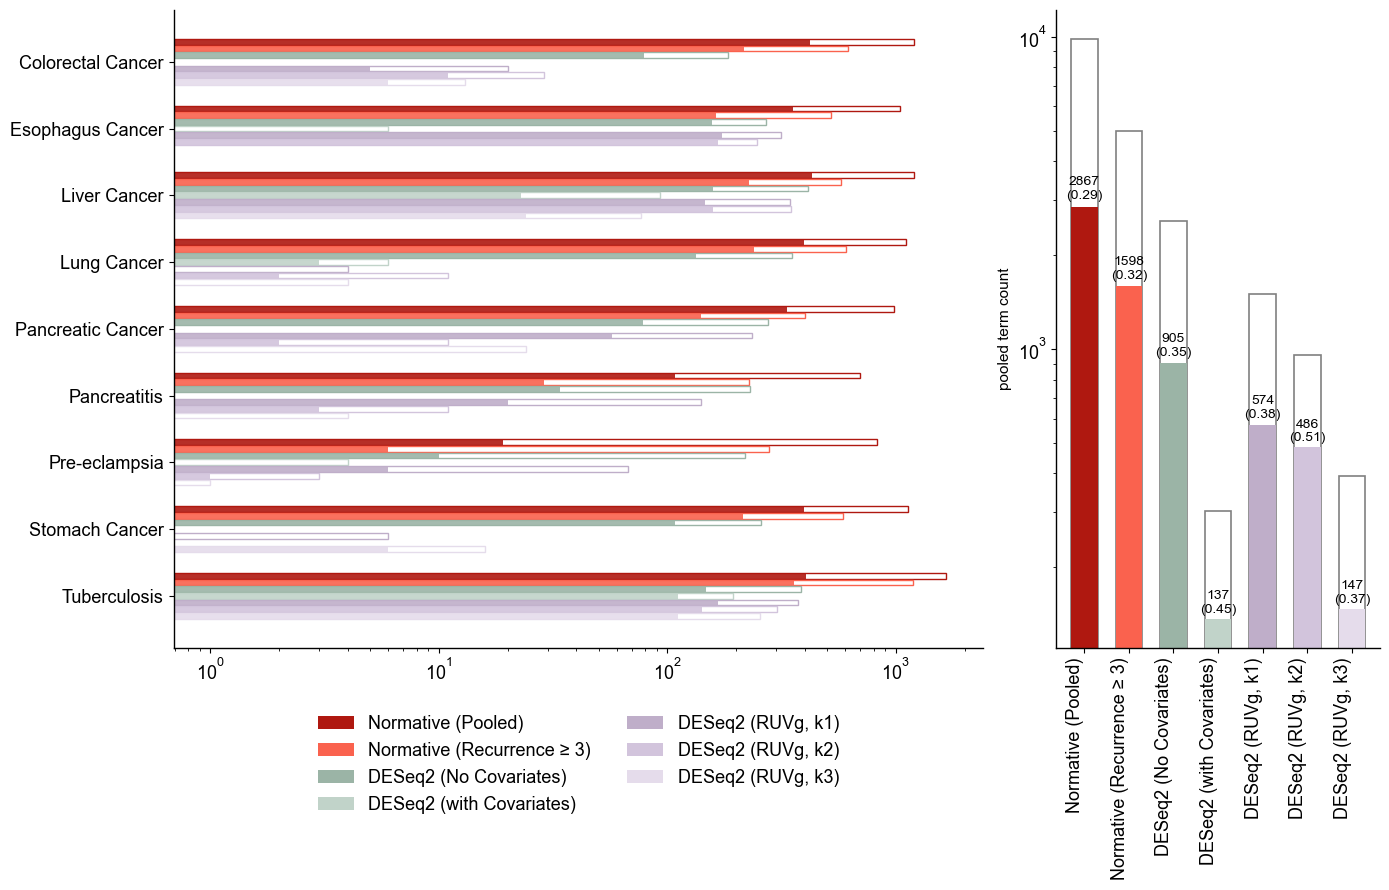

In [30]:
plot_db_hit_bars(path_rates, fname='pathway_db_hit_bars.png', dc=dc, scale='log')

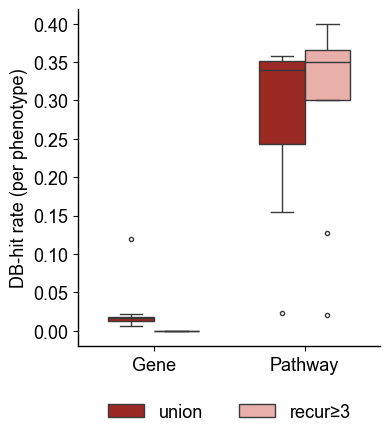

In [35]:
import seaborn as sns

box_rows = []
for level, df in [('Gene', rates), ('Pathway', path_rates)]:
    for method, tag in [('normative_union', 'union'), ('normative_recur3', 'recur≥3')]:
        sub = df[(df.method == method) & df.has_ot_ref]
        for v in sub['db_hit_rate'].fillna(0).values:
            box_rows.append((level, tag, v))
box_df = pd.DataFrame(box_rows, columns=['level', 'recurrence', 'db_hit_rate'])

fig, ax = plt.subplots(figsize=(4, 4.5))
sns.boxplot(data=box_df, x='level', y='db_hit_rate', hue='recurrence',
            palette={'union': '#af1810', 'recur≥3': '#f4a89f'},
            width=0.6, fliersize=3, linewidth=1, ax=ax)
ax.set_ylabel('DB-hit rate (per phenotype)')
ax.set_xlabel('')
ax.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
(dc.HERE / 'Figures').mkdir(exist_ok=True)
fig.savefig(dc.HERE / 'Figures' / 'gene_vs_pathway_recurrence_box.png', dpi=300, bbox_inches='tight')

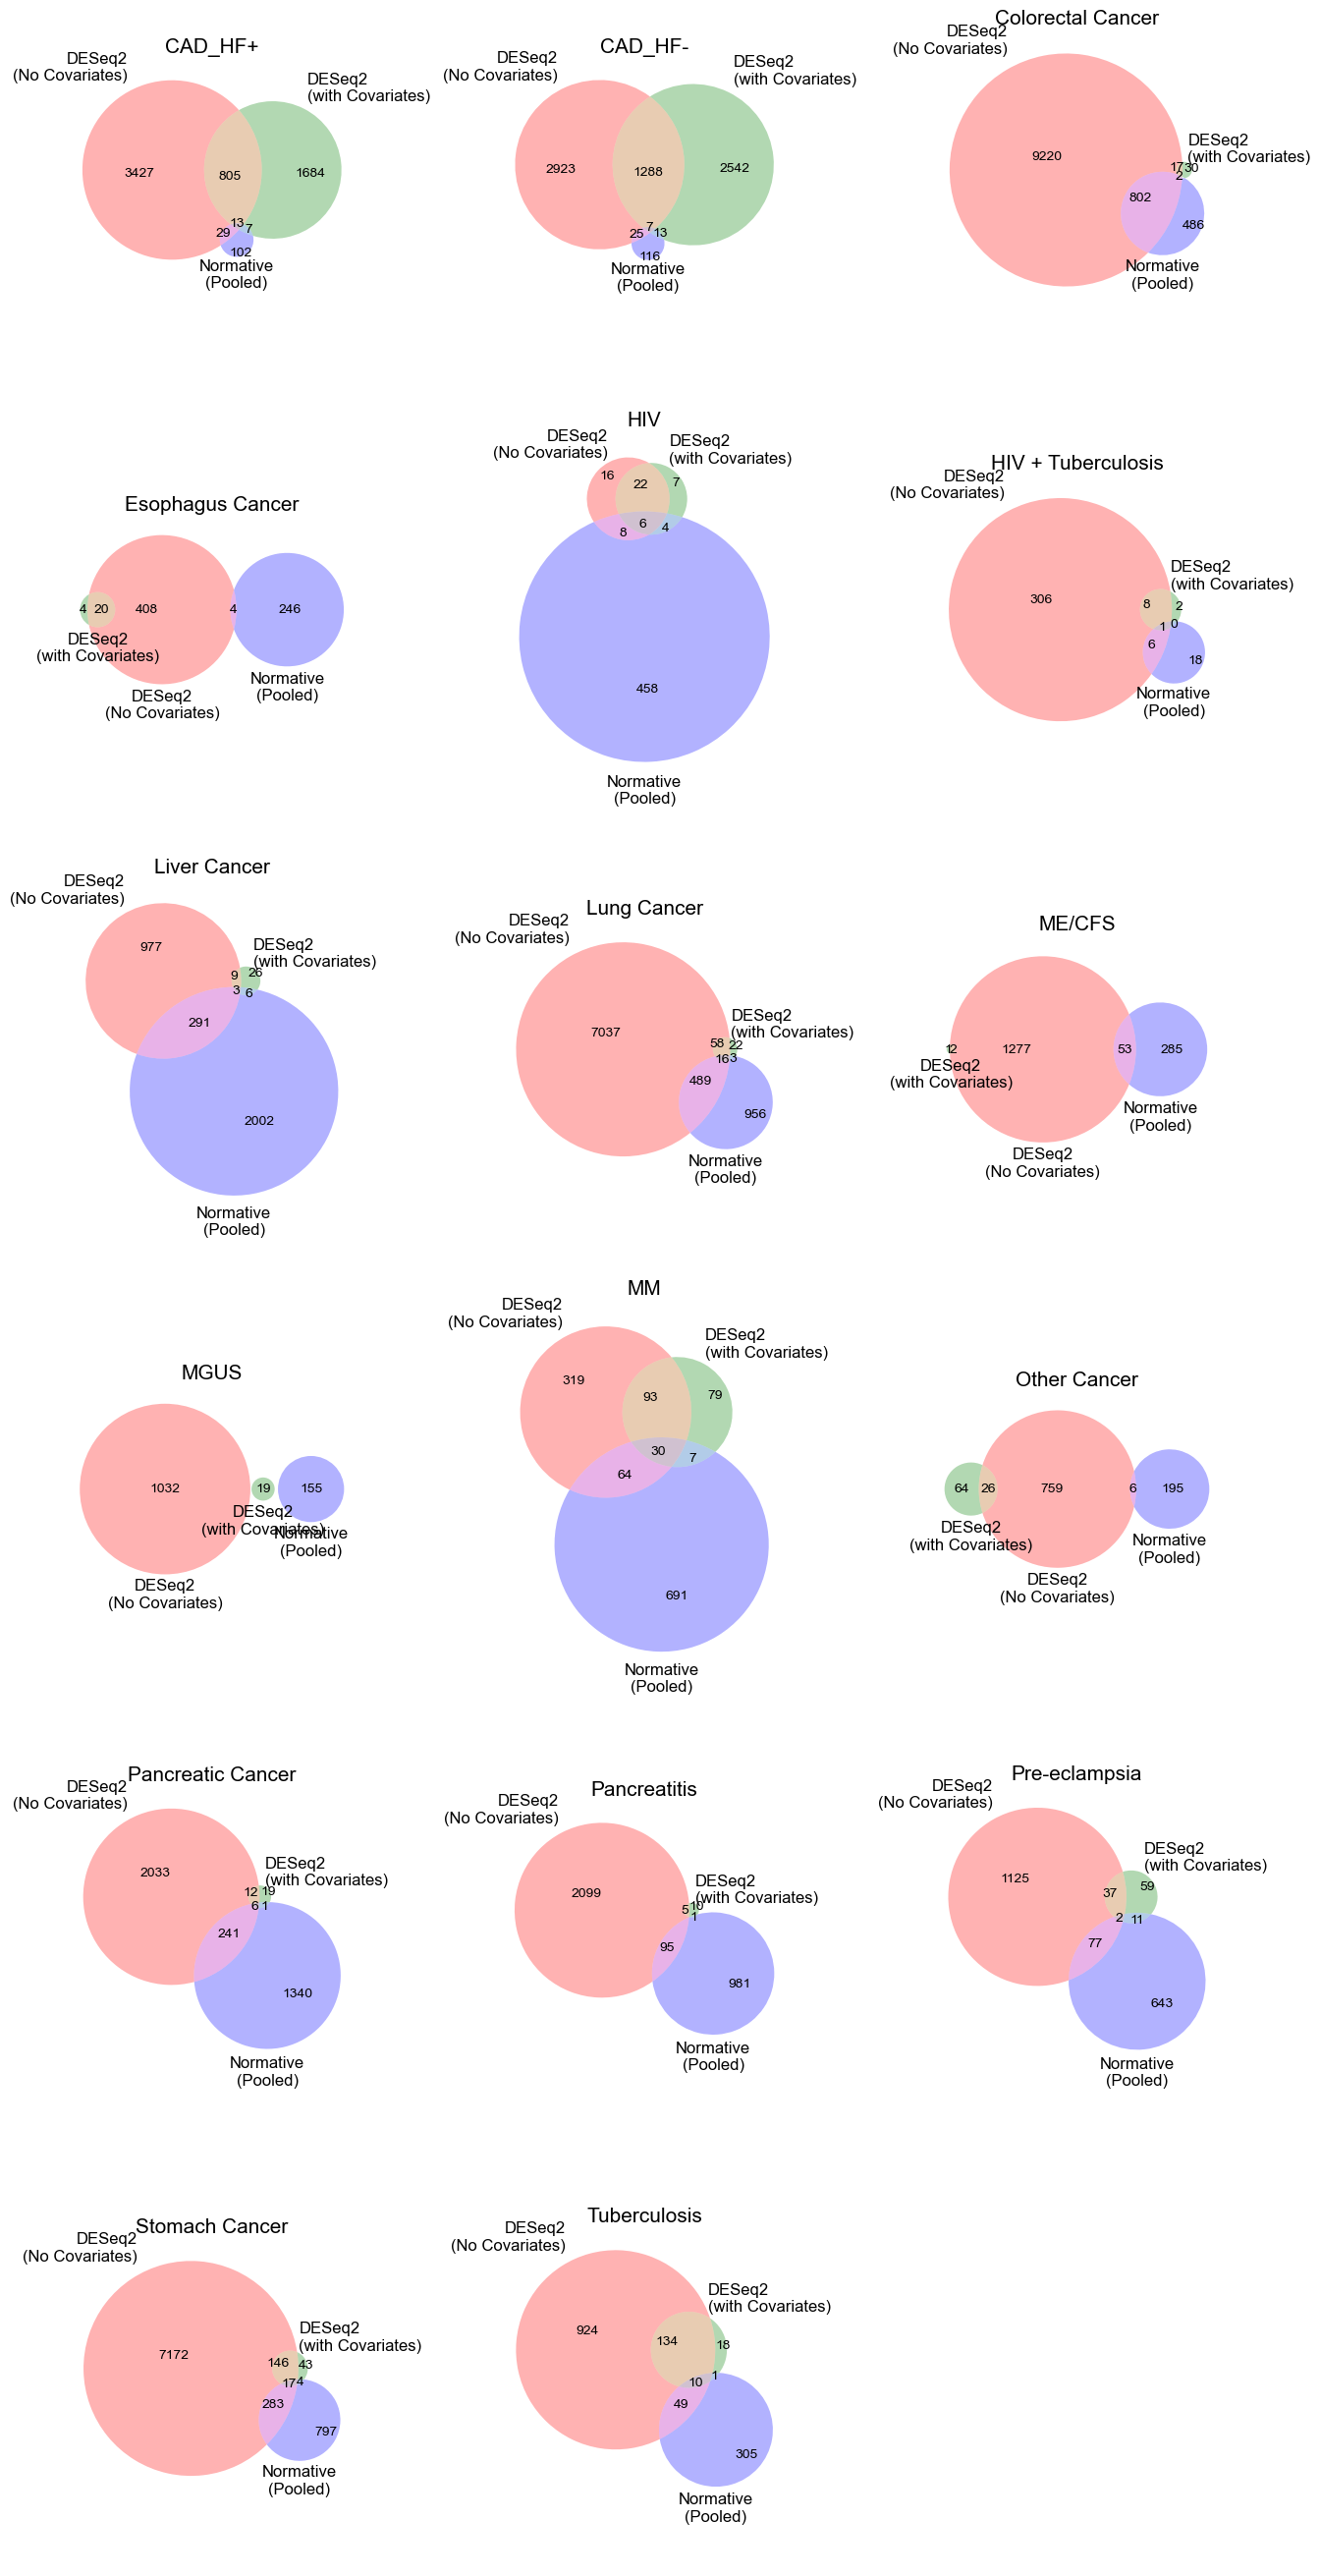

In [38]:
from matplotlib_venn import venn3

sets = dc.gene_venn_sets()
ncols = 3
nrows = -(-len(sets) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()
for ax, (pheno, (a, b, c)) in zip(axes, sets.items()):
    venn3([a, b, c], set_labels=('DESeq2\n(No Covariates)', 'DESeq2\n(with Covariates)', 'Normative\n(Pooled)'), ax=ax, alpha=0.3)
    ax.set_title(pheno)
for ax in axes[len(sets):]:
    ax.axis('off')
plt.tight_layout()
(dc.HERE / 'Figures').mkdir(exist_ok=True)
fig.savefig(dc.HERE / 'Figures' / 'venn_gene_benchmarks.png', bbox_inches='tight')
